In [12]:
import pandas as pd
import pyfpgrowth
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 200) 

In [13]:
# Get the qualifications and the sector is under
qual_sector_df = pd.read_csv('programs.csv')
qual_sector_map = dict(zip(qual_sector_df.Qualification, qual_sector_df.SECTOR))

In [14]:
# get the leads
leads_df = pd.read_csv('Upload_ Leads PHP(TESDA).csv', encoding = "ISO-8859-1")
priority_lead_df = leads_df[leads_df['Priority Level'] == '1st Priority']

# priority mapping
priority_map = dict(zip(leads_df.Company, leads_df['Priority Level']))

# get the name of the companies
priority_companies = priority_lead_df['Company'].dropna()
lead_companies = leads_df['Company'].dropna()

programs_df = pd.read_csv('filter_TVET_EDA_NCR_4A(Clean Data).csv', encoding = "ISO-8859-1")
lead_programs_df = programs_df[programs_df['Institution Name'].isin(lead_companies)].copy()

lead_programs_df = lead_programs_df[['Institution Name', 'Qualification']].copy()
lead_programs_df['Sector'] = lead_programs_df['Qualification'].map(qual_sector_map)

# Initialize
insti_qual = {}
insti_sector = {}
priority_insti_qual = {}
priority_insti_sector = {}

priority_set = set(priority_companies)

for _, row in lead_programs_df.iterrows():
    institution = row['Institution Name']
    qualification = row['Qualification']

    # Get sector safely
    sector = qual_sector_map[qualification]

    # All institutions
    insti_qual.setdefault(institution, []).append(qualification)
    if sector:
        insti_sector.setdefault(institution, []).append(sector)

    # Priority institutions
    if institution in priority_set:
        priority_insti_qual.setdefault(institution, []).append(qualification)
        if sector:
            priority_insti_sector.setdefault(institution, []).append(sector)

In [15]:
programs_df

,Institution Name,City,Province,Region,Reg,Qualification,IsConstruction,Is_Development,Is_Assessment,Trainer Count,Enrolled,Graduates,Number of Accredited Ass Qual,Assessed,Certified
0,PHILIPPINE CALL CENTER INSTITUTE INC.,Makati City,PASMAK,National Capital Region (NCR),NCR,Computer Systems Servicing NC II,False,1,0,17,2569,2773,0,0,0
1,EAST AND WEST CENTER OF EXCELLENCE IN TRAINING CORPORATION,Alaminos,Laguna,Region IVA - CALABARZON,4A,Contact Center Services NC II,False,1,0,8,1792,1615,0,0,0
2,HYPER YOUNG INSTITUTE OF TECHNOLOGY INC.,Pasig City,PAMAMARISAN,National Capital Region (NCR),NCR,Computer Systems Servicing NC II,False,1,1,6,1256,1238,1,969,908
3,CARENET HEALTHCARE INSTITUTE INC.,Makati City,PASMAK,National Capital Region (NCR),NCR,Barista NC II,False,1,1,8,1115,1180,1,567,556
4,THE BIG FIVE TRAINING AND ASSESSMENT CENTER INC.,San Pablo City,Laguna,Region IVA - CALABARZON,4A,Bread and Pastry Production NC II,False,1,1,4,1276,1025,1,821,821
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3322,"ONE STOP WAREHOUSING SOLUTIONS, INC",Taguig City,MUNTIPARLASTAPAT,National Capital Region (NCR),NCR,Warehousing Services NC II,False,1,0,1,23,0,0,0,0
3323,PROVINCIAL TECHNICAL EDUCATION AND SKILLS DEVELOPMENT CENTER (PTESDC) - TAYTAY,Taytay,Rizal,Region IVA - CALABARZON,4A,Bookkeeping NC III,False,0,1,0,0,0,1,108,0
3324,"LYCEUM OF THE PHILIPPINES UNIVERSITY, INC. DOING BUSINESS UNDER THE NAMES AND STYLES OF THE BAYLEAF","Intramuros, City of Manila",City of Manila,National Capital Region (NCR),NCR,Web Development NC III,False,0,1,0,0,0,1,20,0
3325,"BOWLINE TRAINING AND ASSESSMENT CENTER, INC.",Marikina City,PAMAMARISAN,National Capital Region (NCR),NCR,Housekeeping NC III,False,0,1,0,0,0,1,10,0


In [16]:
ncr_df = programs_df[programs_df['Reg'] == 'NCR']
ncr_df['Institution Name'].nunique()

546

In [17]:
ncr_df = programs_df[programs_df['Reg'] == '4A']
ncr_df['Institution Name'].nunique()

543

# Common Combinations of Qualifications

In [18]:
# OVERALL
qual_offered = list(insti_qual.values())
patterns = pyfpgrowth.find_frequent_patterns(qual_offered, 3)
itemset_freq = pd.DataFrame({
    'itemset': list(patterns.keys()),
    'count': list(patterns.values())
})
itemset_freq['support'] = itemset_freq['count'] / len(insti_qual.keys())

# PRIORITY
priority_qual_offered = list(priority_insti_qual.values())
patterns = pyfpgrowth.find_frequent_patterns(priority_qual_offered, 3)
priority_itemset_freq = pd.DataFrame({
    'itemset': list(patterns.keys()),
    'count': list(patterns.values())
})
priority_itemset_freq['support'] = priority_itemset_freq['count'] / len(priority_insti_qual.keys())

In [19]:
priority_itemset_freq.sort_values('count', ascending=False).head(10)

,itemset,count,support
277,"(Bread and Pastry Production NC II,)",15,0.625000
275,"(Housekeeping NC II,)",13,0.541667
276,"(Bread and Pastry Production NC II, Housekeeping NC II)",10,0.416667
273,"(Bread and Pastry Production NC II, Food and Beverage Services NC II)",10,0.416667
272,"(Food and Beverage Services NC II, Housekeeping NC II)",10,0.416667
274,"(Bread and Pastry Production NC II, Food and Beverage Services NC II, Housekeeping NC II)",8,0.333333
254,"(Bartending NC II, Food and Beverage Services NC II)",8,0.333333
264,"(Bread and Pastry Production NC II, Cookery NC II)",8,0.333333
252,"(Bartending NC II, Bread and Pastry Production NC II, Food and Beverage Services NC II)",7,0.291667
250,"(Bartending NC II, Bread and Pastry Production NC II)",7,0.291667


In [20]:
priority_qual_offered = list(priority_insti_qual.values())
priority_qual_offered_w_o_bread = [
    [qual for qual in sublist if qual != "Bread and Pastry Production NC II"]
    for sublist in priority_qual_offered
]
patterns = pyfpgrowth.find_frequent_patterns(priority_qual_offered_w_o_bread, 3)
priority_itemset_freq = pd.DataFrame({
    'itemset': list(patterns.keys()),
    'count': list(patterns.values())
})
priority_itemset_freq['support'] = priority_itemset_freq['count'] / len(priority_insti_qual.keys())
priority_itemset_freq.sort_values('count', ascending=False).to_clipboard()

# Visualizing the Schools

In [25]:
insti_qual_df = pd.DataFrame({
    'Institution':priority_insti_qual.keys(),
    'Qualifications':[set(quals) for quals in priority_insti_qual.values()],
})

insti_qual_df['Priority'] = insti_qual_df.Institution.map(priority_map)
insti_qual_df.to_clipboard()

In [26]:
cleaned_quals = [set(quals) for quals in priority_insti_qual.values()]

insti_sector_df = pd.DataFrame({
    'Institution': list(priority_insti_sector.keys()),
    'Sectors': [
        list(qual_sector_map[q] for q in quals)
        for quals in cleaned_quals
    ],
})

insti_sector_df['Priority'] = insti_sector_df.Institution.map(priority_map)

insti_sector_df['Specialized Sector'] = insti_sector_df.Sectors.apply(
    lambda lst : max(set(lst), key=lst.count)
)

insti_sector_df.value_counts(['Specialized Sector'], normalize=True)
insti_sector_df.to_clipboard()

In [28]:
insti_sector_df['Institution']

0                                                                             TECHVOC SKILLS INC.
1                                                  UNO CAREGIVER AND DOMESTIC MNGT TRAINING, INC.
2                                                   Colegio de Santo Cristo De Burgos Corporation
3                                                                 MECHATRONICS TECHNOLOGIES CORP.
4                                                                 PSAA INTERNATIONAL ACADEMY INC.
5                                                                  REGIONAL TRAINING CENTER - NCR
6                                                               RIGHT FOCUS TRAINING CENTER, INC.
7                                                SOCIO INTER SKILLS TRAINING ACADEMY (SISTA) INC.
8                                   INTERNATIONAL TRAINING CENTER AND HOSPITALITY INSTITUTE, INC.
9                                           SOUTHERN LUZON TECHNOLOGICAL COLLEGE FOUNDATION, INC.
10                  

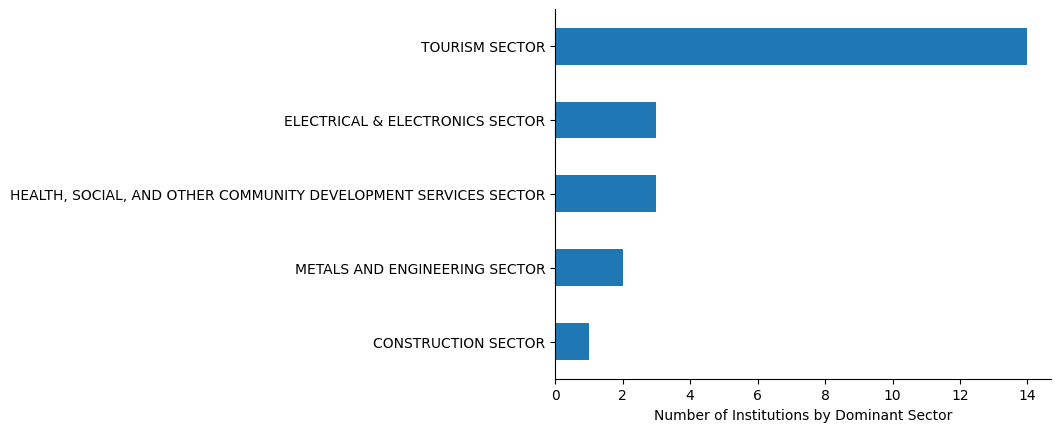

In [ ]:
insti_sector_df.value_counts('Specialized Sector')[::-1].plot(kind='barh')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.ylabel('')
plt.xlabel('Number of Institutions by Dominant Sector');